# Notebook 2 — Nelson-Siegel & NSS Curve Fitting

**Project**: Replication of *"Autoencoder Market Models for Interest Rates"* (Sokol, 2022)

This notebook builds the **classical benchmark** against which we will later measure the VAE.
It fits the Nelson-Siegel (NS, 3 factors) and Nelson-Siegel-Svensson (NSS, 4 factors) bases to every
historical swap curve in our dataset, computes reconstruction RMSE per date, and saves everything
for notebook 4 (comparison) and notebook 7 (P-measure AEMM vs DNS).

### Why this notebook matters for the project

Sokol's main claim is that a 2-dimensional VAE achieves **"similar accuracy to the classical
Nelson-Siegel basis with three latent factors"** (§2.4.3 of the paper). To verify this claim on our
own data we need:

1. A correctly-implemented NS fit with a **defensible choice of $\lambda$**,
2. Per-date reconstruction RMSE that we can later compare to the VAE (Wilcoxon test in nb4),
3. The NS latent factors $(\beta_1,\beta_2,\beta_3)$ in time-series form to compare with the VAE
   latent factors $(z_1,z_2)$ in nb7 (Dynamic Nelson-Siegel vs Autoregressive AEMM).

### Pipeline of this notebook

1. Load the cleaned long-format CSV from notebook 1.
2. Recall the math: NS / NSS basis functions and how we fit them.
3. Implement vectorised NS fitting and per-date eNS / NSS fitting.
4. **Cross-validate $\lambda$** over a grid, pooling all currencies, to choose one global value.
5. Fit all three models to every date × every currency.
6. Produce the diagnostic plots used in the report:
   - RMSE distributions per currency (replicates Figure 11 of Sokol 2022),
   - RMSE distribution pooled across currencies (replicates Figure 10),
   - Time series of NS latent factors,
   - Example fits (best / median / worst dates),
   - Per-tenor residuals heatmap (shows which maturities NS struggles with).
7. Save everything to `ns_results.pkl`.

### Technical choices we commit to (with justification)

| Choice                                  | Value                              | Why                                                                                |
| ---                                     | ---                                | ---                                                                                |
| NS $\lambda$                            | chosen by pooled cross-validation  | Removes arbitrary choice; gives NS its best shot before the VAE comparison.        |
| eNS (extension)                         | included                           | Tighter intra-model benchmark ($\lambda$ re-optimised per date).                   |
| NSS (4-factor)                          | included                           | Upper reference: Sokol uses it implicitly; shows how far a 4-parameter basis goes. |
| Rates representation                    | decimals internally, bp in plots   | Matches paper convention ("Swap Rate RMSE (bp)" on Figures 9-12).                  |
| In-sample / out-of-sample split for NS? | **not applied here**               | NS is an independent per-date fit, not a trained model. OOS matters in nb3 (VAE).  |


## 0 — Imports & setup

In [1]:
import pickle
import time
import warnings
from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize, minimize_scalar

warnings.filterwarnings("ignore")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

BP_PER_UNIT = 10000.0   # rates are stored in decimal form; 1 bp = 0.0001

## 1 — Load the cleaned dataset


⚠️ CHF is excluded

While preparing the data we noticed that the CHF swap series we had access to was inconsistent
with the real Swiss market levels (CHF 2Y quoted at 3–6% in 2023–2025, whereas the true CHF SARON
2Y was ~0.5–1.8%). The problem was traced to a non-SARON Bloomberg ticker that predates the
LIBOR-CHF retirement. Rather than contaminate the multi-currency VAE with a clearly wrong series,
we **drop CHF** and keep the remaining 7 currencies. The analysis is therefore performed on:

**AUD, CAD, DKK, EUR, GBP, JPY, USD**


In [41]:
DATA_PATH = Path("data/df_multi.csv")

In [42]:
EXCLUDE_CURRENCIES = {"CHF"} 
df_long = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df_long = df_long[~df_long["currency"].isin(EXCLUDE_CURRENCIES)].copy()

In [43]:
CURRENCIES = sorted(df_long["currency"].unique())
TARGET_TENORS = [2, 3, 5, 10, 15, 20, 30]
TENORS = np.array(TARGET_TENORS, dtype=float)
TENOR_COLS = [str(t) for t in TARGET_TENORS]    # column names in the CSV are strings

In [44]:
# Reshape the long-format CSV into a dict[ccy -> DataFrame(dates, tenor-cols)].
swap_aligned: dict[str, pd.DataFrame] = {}
for ccy in CURRENCIES:
    sub = (df_long[df_long["currency"] == ccy]
           .set_index("Date")
           .sort_index()
           [TENOR_COLS]
           .copy())
    sub.columns = TARGET_TENORS             
    swap_aligned[ccy] = sub

In [45]:
dates_ref = swap_aligned[CURRENCIES[0]].index
print(f"Loaded {len(CURRENCIES)} currencies: {CURRENCIES}")
print(f"Dates: {len(dates_ref)}  "
      f"({dates_ref.min().date()} -> {dates_ref.max().date()})")
print(f"Tenors: {TARGET_TENORS}")
for ccy in CURRENCIES:
    print(f"  {ccy}: shape={swap_aligned[ccy].shape}")

Loaded 7 currencies: ['AUD', 'CAD', 'DKK', 'EUR', 'GBP', 'JPY', 'USD']
Dates: 774  (2023-01-30 -> 2026-01-15)
Tenors: [2, 3, 5, 10, 15, 20, 30]
  AUD: shape=(774, 7)
  CAD: shape=(774, 7)
  DKK: shape=(774, 7)
  EUR: shape=(774, 7)
  GBP: shape=(774, 7)
  JPY: shape=(774, 7)
  USD: shape=(774, 7)


## 2 — Theory and intuition

Before coding anything we recall the Nelson-Siegel model so that every team member (and the
eventual reader of the report) knows exactly what we are fitting.

### 2.1 Nelson-Siegel (3 factors)

Nelson and Siegel (1987) proposed the following parametric form for the continuously-compounded
zero rate at maturity $\tau$:

$$
R(\tau) \;=\; \beta_1
\;+\; \beta_2 \left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}\right)
\;+\; \beta_3 \left(\frac{1-e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right).
$$

The three factors have an intuitive interpretation:

- $\beta_1$ — **level**: the long-term rate (as $\tau\to\infty$ both factor loadings of $\beta_2$
  and $\beta_3$ vanish, so $R(\infty)=\beta_1$).
- $\beta_2$ — **slope**: governs the short-end. As $\tau\to 0^+$, the loading
  $\tfrac{1-e^{-\lambda\tau}}{\lambda\tau}\to 1$, so $R(0)=\beta_1+\beta_2$, i.e. $\beta_2$ is
  minus the spread between short and long rates. A negative $\beta_2$ means an upward-sloping curve.
- $\beta_3$ — **curvature**: controls the "hump" of the curve, peaking at an intermediate maturity
  determined by $\lambda$.

The parameter $\lambda > 0$ controls the **decay rate** of the exponential terms. It determines
**where along the curve the hump is located**. A standard Diebold-Li calibration places the
curvature loading at its maximum near $\tau \approx 2.5$ years, which corresponds to $\lambda \approx 0.73$.
We will not trust this value blindly — we choose $\lambda$ empirically in §5.

### 2.2 Why we can follow Sokol and fit NS directly to swap rates

Strictly speaking NS was defined for zero rates; swap rates are par rates of coupon-paying
instruments. But Sokol (§2.1) argues that encoding *swap rates directly* is actually preferable
because it removes the intermediate curve-building step and its subjective choices. We follow the
exact same convention: NS (and NSS and the VAE) all consume swap rates $S_n$ at maturities
$\tau_n$, and reconstruction error is measured at the swap-rate level in basis points.

### 2.3 Nelson-Siegel-Svensson (4 factors)

Svensson (1994) added a second curvature term with its own decay rate $\lambda_2$:

$$
R(\tau) \;=\; \beta_1
\;+\; \beta_2 \phi(\lambda_1\tau)
\;+\; \beta_3 \bigl[\phi(\lambda_1\tau) - e^{-\lambda_1\tau}\bigr]
\;+\; \beta_4 \bigl[\phi(\lambda_2\tau) - e^{-\lambda_2\tau}\bigr],
$$

where $\phi(x) := (1-e^{-x})/x$. This gives NSS **two humps**, which lets it fit curves with more
complex shapes (e.g. a peak near 3Y and another near 15Y). On our data NSS will clearly dominate
NS — the question is *by how much*, and whether a 2-dimensional VAE can close the gap.

### 2.4 How we fit

- **NS with fixed $\lambda$**: given $\lambda$, the map $(\beta_1,\beta_2,\beta_3)\mapsto S$ is
  linear, so ordinary least squares solves it in closed form. This makes NS fitting extremely fast
  and fully vectorised across dates.
- **eNS** (Extended NS): we let $\lambda$ vary **per date**. For each date we solve a 1-D
  optimisation for $\lambda$, nested with OLS for $(\beta_1,\beta_2,\beta_3)$ given $\lambda$.
  eNS is a strict upper bound (in fit quality) on NS with fixed $\lambda$, and has a matching 3-factor
  latent space.
- **NSS**: we optimise $(\lambda_1,\lambda_2)$ jointly per date (Nelder-Mead), nested with OLS
  for $(\beta_1,\beta_2,\beta_3,\beta_4)$. This is the 4-factor benchmark.

**Which one is the primary benchmark?**
Following Sokol (§2.4.3) we treat **NS with fixed global $\lambda$** as the primary comparison
against the VAE. eNS and NSS are additional reference points that show how far purely classical
methods can go when given more per-date flexibility.


## 3 — Basis functions

In [46]:
def ns_basis(tau: np.ndarray, lam: float) -> np.ndarray:
    """
    Nelson-Siegel basis functions evaluated at a vector of maturities.

    Parameters
    ----------
    tau : 1D array of maturities in years, shape (N,).
    lam : decay parameter lambda (>0).

    Returns
    -------
    B : (N, 3) matrix where the three columns are
        - B[:,0] = 1                                 (level loading)
        - B[:,1] = (1 - exp(-lam*tau)) / (lam*tau)   (slope loading)
        - B[:,2] = B[:,1] - exp(-lam*tau)            (curvature loading)
    For tau -> 0, the loading of \beta_2 tends to 1 and the loading of \beta_3 tends to 0,
    giving R(0) = beta_1 + beta_2.
    """
    tau = np.asarray(tau, dtype=float)
    lt = lam * tau
    # Guard against the singularity at tau -> 0 (irrelevant for our tenors but clean code).
    with np.errstate(divide="ignore", invalid="ignore"):
        f1 = np.where(lt > 1e-10, (1.0 - np.exp(-lt)) / lt, 1.0)
    f2 = f1 - np.exp(-lt)
    return np.column_stack([np.ones_like(tau), f1, f2])


def nss_basis(tau: np.ndarray, lam1: float, lam2: float) -> np.ndarray:
    """
    Nelson-Siegel-Svensson basis: adds a second hump with its own decay lam2.
    Returns a (N, 4) matrix.
    """
    tau = np.asarray(tau, dtype=float)
    lt1 = lam1 * tau
    lt2 = lam2 * tau
    with np.errstate(divide="ignore", invalid="ignore"):
        f1 = np.where(lt1 > 1e-10, (1.0 - np.exp(-lt1)) / lt1, 1.0)
        g1 = f1 - np.exp(-lt1)
        f2 = np.where(lt2 > 1e-10, (1.0 - np.exp(-lt2)) / lt2, 1.0)
        g2 = f2 - np.exp(-lt2)
    return np.column_stack([np.ones_like(tau), f1, g1, g2])

### Visualising the NS basis

The three NS loadings as functions of maturity $\tau$. The figure helps build intuition for the
role of each factor: $\beta_1$ is a flat level, $\beta_2$ loads onto the short end, and $\beta_3$
creates a bump at an intermediate maturity controlled by $\lambda$.


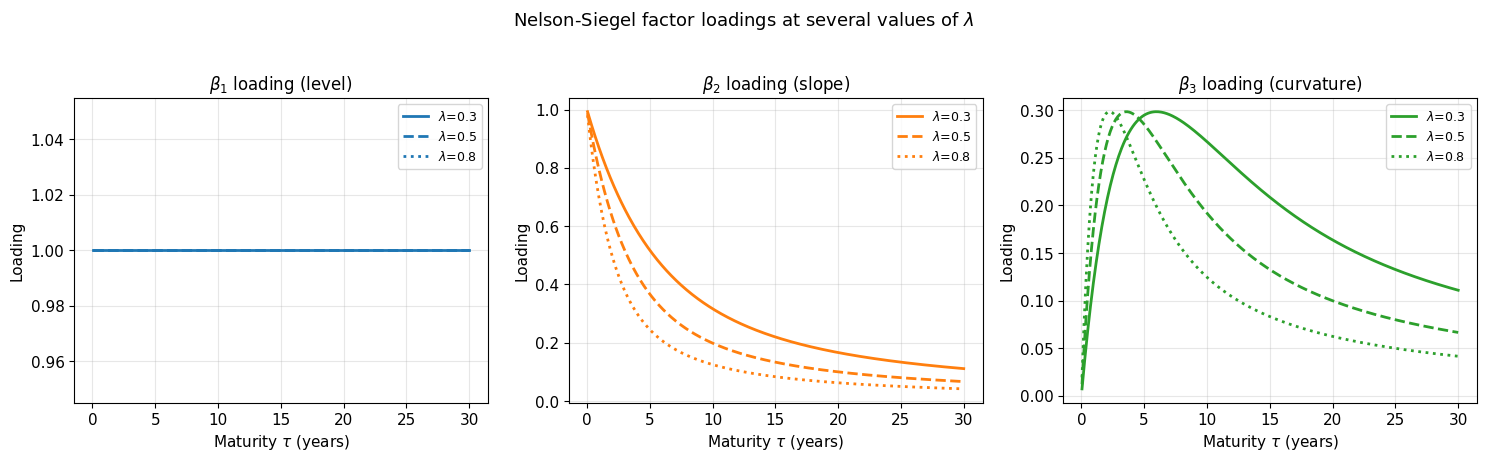

In [23]:
tau_plot = np.linspace(0.05, 30, 400)
lambdas_to_show = [0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["tab:blue", "tab:orange", "tab:green"]
labels = [r"$\beta_1$ loading (level)",
          r"$\beta_2$ loading (slope)",
          r"$\beta_3$ loading (curvature)"]

for k, (ax, label) in enumerate(zip(axes, labels)):
    for lam, color_ls in zip(lambdas_to_show, ["-", "--", ":"]):
        B = ns_basis(tau_plot, lam)
        ax.plot(tau_plot, B[:, k], color_ls, linewidth=2,
                color=colors[k], label=f"$\\lambda$={lam}")
    ax.set_xlabel(r"Maturity $\tau$ (years)")
    ax.set_ylabel("Loading")
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle("Nelson-Siegel factor loadings at several values of $\\lambda$",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02a_ns_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Fit functions

We implement three routines:

1. `fit_ns_vectorised(rates_matrix, tenors, lam)` — NS with fixed $\lambda$, fits **all dates at once**
   via a single `np.linalg.lstsq` call. This is what we use for the λ-cross-validation and for the
   final production fit.
2. `fit_ens_one(rates, tenors, ...)` — eNS with $\lambda$ re-optimised **per date**. Uses
   `scipy.optimize.minimize_scalar` on a bounded 1-D interval.
3. `fit_nss_one(rates, tenors, ...)` — NSS with $(\lambda_1, \lambda_2)$ jointly optimised per date
   via Nelder-Mead.

We wrap per-date results in a `NamedTuple` for clarity when we need to introspect individual fits.


In [53]:
class NSResult(NamedTuple):
    """Per-date NS / eNS / NSS fit result."""
    beta: np.ndarray      # (3,) for NS/eNS, (4,) for NSS
    lam: float            # lambda (lam1 for NSS)
    lam2: float           # second lambda for NSS, NaN otherwise
    fitted: np.ndarray    # (N,) fitted swap rates
    residuals: np.ndarray # (N,) swap rates - fitted
    rmse: float           # sqrt(mean(resid^2)) in basis points


def fit_ns_vectorised(rates_matrix: np.ndarray, tenors: np.ndarray, lam: float):
    """
    Fit NS with fixed lambda to *every row* of rates_matrix at once.

    Parameters
    ----------
    rates_matrix : (T, N) matrix of swap rates in decimal form.
    tenors       : (N,) maturities in years.
    lam          : fixed decay parameter.

    Returns
    -------
    betas     : (T, 3) factor loadings.
    fitted    : (T, N) fitted rates.
    residuals : (T, N) residuals.
    rmse_bp   : (T,)  per-date RMSE in basis points.
    """
    B = ns_basis(tenors, lam)                                   # (N, 3)
    # Solve B @ beta_t = r_t for every t. Stacking r_t as columns of r_matrix.T
    # turns this into a single (N, T) system that lstsq handles in one call.
    betas_T, *_ = np.linalg.lstsq(B, rates_matrix.T, rcond=None)  # (3, T)
    betas = betas_T.T                                            # (T, 3)
    fitted = betas @ B.T                                         # (T, N)
    residuals = rates_matrix - fitted
    rmse_bp = np.sqrt(np.mean(residuals**2, axis=1)) * BP_PER_UNIT
    return betas, fitted, residuals, rmse_bp


def fit_ens_one(rates: np.ndarray, tenors: np.ndarray,
                lam_bounds: tuple[float, float] = (0.05, 15.0)) -> NSResult:
    """
    Per-date eNS fit: optimise lambda, OLS for beta conditional on lambda.
    """
    def obj(la: float) -> float:
        B = ns_basis(tenors, la)
        beta = np.linalg.lstsq(B, rates, rcond=None)[0]
        return float(np.sum((rates - B @ beta) ** 2))

    res = minimize_scalar(obj, bounds=lam_bounds, method="bounded",
                          options={"xatol": 1e-5})
    la = float(res.x)
    B = ns_basis(tenors, la)
    beta = np.linalg.lstsq(B, rates, rcond=None)[0]
    fitted = B @ beta
    resid = rates - fitted
    rmse = float(np.sqrt(np.mean(resid ** 2)) * BP_PER_UNIT)
    return NSResult(beta=beta, lam=la, lam2=np.nan,
                    fitted=fitted, residuals=resid, rmse=rmse)


def fit_nss_one(rates: np.ndarray, tenors: np.ndarray,
                lam1_init: float = 0.5, lam2_init: float = 0.15,
                lam_bounds: tuple[float, float] = (0.05, 15.0)) -> NSResult:
    """
    Per-date NSS fit: optimise (lam1, lam2) by Nelder-Mead, OLS for betas.

    A soft penalty forbids lam1 ~ lam2 (otherwise the two curvature terms are
    numerically degenerate and the normal equations become ill-conditioned).
    """
    def obj(p: np.ndarray) -> float:
        la1, la2 = float(p[0]), float(p[1])
        if (la1 < lam_bounds[0] or la1 > lam_bounds[1] or
            la2 < lam_bounds[0] or la2 > lam_bounds[1]):
            return 1e12
        if abs(la1 - la2) < 0.01:       # avoid degenerate configuration
            return 1e12
        B = nss_basis(tenors, la1, la2)
        beta = np.linalg.lstsq(B, rates, rcond=None)[0]
        return float(np.sum((rates - B @ beta) ** 2))

    res = minimize(obj, x0=[lam1_init, lam2_init], method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-10, "maxiter": 400})
    la1, la2 = float(res.x[0]), float(res.x[1])
    B = nss_basis(tenors, la1, la2)
    beta = np.linalg.lstsq(B, rates, rcond=None)[0]
    fitted = B @ beta
    resid = rates - fitted
    rmse = float(np.sqrt(np.mean(resid ** 2)) * BP_PER_UNIT)
    return NSResult(beta=beta, lam=la1, lam2=la2,
                    fitted=fitted, residuals=resid, rmse=rmse)

### Quick sanity check on a single date

In [54]:
# Fit the three models on the first USD observation and print the results.
test_rates = swap_aligned["USD"].iloc[0].values.astype(float)
test_date  = swap_aligned["USD"].index[0]

_, _, _, rmse_ns_vec = fit_ns_vectorised(test_rates[None, :], TENORS, lam=0.5)
res_ens  = fit_ens_one(test_rates, TENORS)
res_nss  = fit_nss_one(test_rates, TENORS)

print(f"Sanity check — USD, {test_date.date()}")
print(f"  NS  (lambda=0.5 fixed)  RMSE = {float(rmse_ns_vec[0]):6.2f} bp")
print(f"  eNS (lambda optimised)  RMSE = {res_ens.rmse:6.2f} bp   lambda* = {res_ens.lam:.3f}")
print(f"  NSS (4 factors)         RMSE = {res_nss.rmse:6.2f} bp   "
      f"(lam1, lam2) = ({res_nss.lam:.3f}, {res_nss.lam2:.3f})")

Sanity check — USD, 2023-01-30
  NS  (lambda=0.5 fixed)  RMSE =  10.80 bp
  eNS (lambda optimised)  RMSE =   8.33 bp   lambda* = 12.984
  NSS (4 factors)         RMSE =   2.22 bp   (lam1, lam2) = (12.775, 0.116)


the hierarchy of erros is logical : NSS<eNS<NS

Allowing λ to vary freely reveals that the optimal value can become extremely large,
effectively concentrating the curvature at very short maturities.

This behaviour highlights a limitation of the Nelson-Siegel specification:
it attempts to compensate for its lack of flexibility by pushing parameters
to extreme values, rather than genuinely capturing the underlying curve shape.

In contrast, the NSS model achieves a significantly lower RMSE by introducing
an additional degree of freedom, allowing it to represent multiple curvature regions.

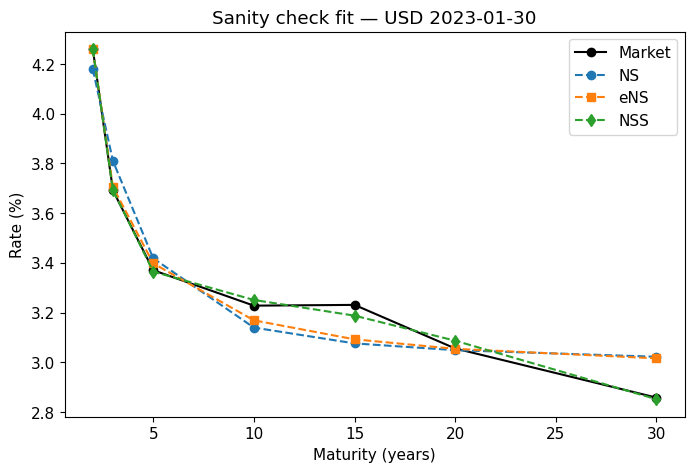

In [52]:
B_ns = ns_basis(TENORS, 0.5)
beta_ns = np.linalg.lstsq(B_ns, test_rates, rcond=None)[0]
fit_ns = B_ns @ beta_ns

fit_ens = res_ens.fitted
fit_nss = res_nss.fitted


plt.figure(figsize=(8, 5))
plt.plot(TENORS, 100 * test_rates, "ko-", label="Market")
plt.plot(TENORS, 100 * fit_ns, "o--", label="NS")
plt.plot(TENORS, 100 * fit_ens, "s--", label="eNS")
plt.plot(TENORS, 100 * fit_nss, "d--", label="NSS")
plt.xlabel("Maturity (years)")
plt.ylabel("Rate (%)")
plt.title(f"Sanity check fit — USD {test_date.date()}")
plt.legend()
plt.grid()
plt.show()

## 5 — Cross-validation of $\lambda$ (pooled across currencies)

Before we run the big production fit we need to commit to a value for the NS decay parameter
$\lambda$. We refuse to just pick "0.4 because Diebold-Li" — that value was derived for short-dated
US Treasuries, not long-dated OIS swaps, and it is not guaranteed to be optimal on our dataset.

### Procedure

1. Build a grid of candidate $\lambda$ values, e.g. 40 equally-spaced points in $[0.05, 2.0]$.
2. For each $\lambda$, fit NS (closed form) to **every** $(\text{date}, \text{currency})$ observation
   in the dataset — because the fit is vectorised this costs only a handful of milliseconds per grid
   point.
3. Compute the **mean pooled RMSE** across all observations. This is the quantity we want to minimise.
4. Pick $\lambda^{\star} = \arg\min_\lambda \overline{\text{RMSE}}_{\text{pooled}}(\lambda)$.

### Why pooled (and not per-currency)?

The multi-currency VAE (nb3) and the CVAE will share a single set of weights across currencies,
so the fairest classical counterpart is a **single global $\lambda$**. A per-currency $\lambda$
would silently give NS an advantage the VAE cannot have, biasing the eventual comparison.


In [64]:
# Build the pooled rates matrix (all currencies stacked on top of each other).
pooled_rates = np.vstack([swap_aligned[c].values.astype(float) for c in CURRENCIES])
print(f"Pooled rates matrix: {pooled_rates.shape[0]} observations x {pooled_rates.shape[1]} tenors")

# Grid of lambda candidates.
lam_grid = np.linspace(0.05, 2.0, 40)

# For each lambda, one vectorised fit on the full pooled matrix.
mean_rmse_per_lam = np.empty(len(lam_grid))
median_rmse_per_lam = np.empty(len(lam_grid))
t0 = time.time()
for i, lam in enumerate(lam_grid):
    _, _, _, rmse_bp = fit_ns_vectorised(pooled_rates, TENORS, lam)
    mean_rmse_per_lam[i]   = rmse_bp.mean()
    median_rmse_per_lam[i] = np.median(rmse_bp)
print(f"Grid search time: {time.time() - t0:.2f}s")

i_opt   = int(np.argmin(mean_rmse_per_lam))
LAM_STAR = float(lam_grid[i_opt])
print(f"\nOptimal lambda (pooled, mean RMSE criterion): {LAM_STAR:.4f}")
print(f"  Min pooled mean RMSE   = {mean_rmse_per_lam[i_opt]:.3f} bp")
print(f"  Min pooled median RMSE = {median_rmse_per_lam[i_opt]:.3f} bp")

Pooled rates matrix: 5418 observations x 7 tenors
Grid search time: 0.14s

Optimal lambda (pooled, mean RMSE criterion): 0.5000
  Min pooled mean RMSE   = 6.769 bp
  Min pooled median RMSE = 6.383 bp


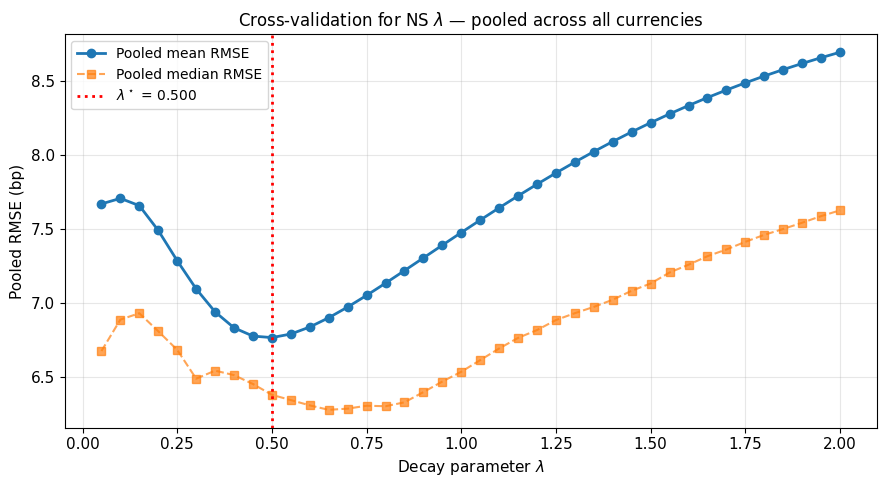

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lam_grid, mean_rmse_per_lam, "o-", linewidth=2,
        color="tab:blue", label="Pooled mean RMSE")
ax.plot(lam_grid, median_rmse_per_lam, "s--", linewidth=1.5, alpha=0.7,
        color="tab:orange", label="Pooled median RMSE")
ax.axvline(LAM_STAR, color="red", linestyle=":", linewidth=2,
           label=rf"$\lambda^\star$ = {LAM_STAR:.3f}")
ax.set_xlabel(r"Decay parameter $\lambda$")
ax.set_ylabel("Pooled RMSE (bp)")
ax.set_title(r"Cross-validation for NS $\lambda$ — pooled across all currencies",
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02b_lambda_cv.png", dpi=150, bbox_inches="tight")
plt.show()

The pooled RMSE curve exhibits a clear interior minimum around λ≈0.5, which indicates that the Nelson-Siegel basis has a well-defined best global decay parameter on our dataset. The objective is fairly flat around the minimiser, suggesting that the benchmark is reasonably robust to moderate perturbations of λ. 
We select $\lambda^{\star}$ by minimising the pooled mean RMSE across all date-currency observations, while also reporting the pooled median RMSE to show that the conclusion is not driven by a few extreme observations.


## 6 — Fit NS, eNS, NSS to every (currency, date)

Now the big production run:

- **NS** uses `fit_ns_vectorised` with $\lambda^{\star}$ from §5 — near-instant.
- **eNS** and **NSS** loop over dates because the per-date nonlinear optimisation does not trivially
  vectorise. We report the total wall time at the end.


In [56]:
fit_results: dict[str, dict] = {}
t_global = time.time()

for ccy in CURRENCIES:
    df = swap_aligned[ccy]
    rates_matrix = df.values.astype(float)
    dates = df.index
    T = len(dates)

    # ------- NS (vectorised at LAM_STAR) -------
    ns_betas, ns_fit, ns_res, ns_rmse = fit_ns_vectorised(rates_matrix, TENORS, LAM_STAR)

    # ------- eNS and NSS (per-date) -------
    ens_betas = np.zeros((T, 3))
    ens_lam   = np.zeros(T)
    ens_rmse  = np.zeros(T)
    ens_res   = np.zeros_like(rates_matrix)

    nss_betas = np.zeros((T, 4))
    nss_lam1  = np.zeros(T)
    nss_lam2  = np.zeros(T)
    nss_rmse  = np.zeros(T)
    nss_res   = np.zeros_like(rates_matrix)

    for i in range(T):
        r = rates_matrix[i]
        r_ens = fit_ens_one(r, TENORS)
        ens_betas[i] = r_ens.beta
        ens_lam[i]   = r_ens.lam
        ens_rmse[i]  = r_ens.rmse
        ens_res[i]   = r_ens.residuals

        r_nss = fit_nss_one(r, TENORS)
        nss_betas[i] = r_nss.beta
        nss_lam1[i]  = r_nss.lam
        nss_lam2[i]  = r_nss.lam2
        nss_rmse[i]  = r_nss.rmse
        nss_res[i]   = r_nss.residuals

    fit_results[ccy] = {
        "dates":    dates,
        "rates":    rates_matrix,
        "ns":  dict(betas=ns_betas,  fitted=ns_fit,  residuals=ns_res,  rmse=ns_rmse),
        "ens": dict(betas=ens_betas, fitted=None,    residuals=ens_res, rmse=ens_rmse,
                    lam=ens_lam),
        "nss": dict(betas=nss_betas, fitted=None,    residuals=nss_res, rmse=nss_rmse,
                    lam1=nss_lam1, lam2=nss_lam2),
    }

    print(f"  {ccy}: NS mean={ns_rmse.mean():5.2f}bp  "
          f"eNS mean={ens_rmse.mean():5.2f}bp  "
          f"NSS mean={nss_rmse.mean():5.2f}bp")

  AUD: NS mean=10.00bp  eNS mean= 8.90bp  NSS mean= 2.03bp
  CAD: NS mean= 7.43bp  eNS mean= 6.77bp  NSS mean= 2.25bp
  DKK: NS mean= 8.31bp  eNS mean= 7.73bp  NSS mean= 2.04bp
  EUR: NS mean= 6.35bp  eNS mean= 5.82bp  NSS mean= 1.02bp
  GBP: NS mean= 2.53bp  eNS mean= 2.36bp  NSS mean= 0.45bp
  JPY: NS mean= 6.49bp  eNS mean= 2.59bp  NSS mean= 1.53bp
  USD: NS mean= 6.28bp  eNS mean= 5.21bp  NSS mean= 1.32bp


### Summary table

In [69]:
rows = []
for ccy in CURRENCIES:
    for model_name, key in [("NS", "ns"), ("eNS", "ens"), ("NSS", "nss")]:
        arr = fit_results[ccy][key]["rmse"]
        rows.append({
            "currency":  ccy,
            "model":     model_name,
            "mean_bp":   arr.mean(),
            "median_bp": np.median(arr),
            "p95_bp":    np.percentile(arr, 95),
            "max_bp":    arr.max(),
        })

summary = pd.DataFrame(rows)
summary_wide = summary.pivot(index="currency", columns="model",
                              values=["mean_bp", "median_bp"])
print("Per-currency summary (bp):")
print(summary.to_string(index=False, float_format="%6.2f"))

print("\nPooled across all currencies (bp):")
pooled = {}
for model_name, key in [("NS", "ns"), ("eNS", "ens"), ("NSS", "nss")]:
    arr = np.concatenate([fit_results[c][key]["rmse"] for c in CURRENCIES])
    pooled[model_name] = {
        "mean":   arr.mean(),
        "median": np.median(arr),
        "p95":    np.percentile(arr, 95),
    }
print(pd.DataFrame(pooled).T.round(2))

Per-currency summary (bp):
currency model  mean_bp  median_bp  p95_bp  max_bp
     AUD    NS    10.00       9.47   16.23   20.89
     AUD   eNS     8.90       8.48   14.85   20.20
     AUD   NSS     2.03       1.54    5.82    9.79
     CAD    NS     7.43       7.00   12.05   25.16
     CAD   eNS     6.77       6.35   11.68   25.49
     CAD   NSS     2.25       1.65    6.07   23.32
     DKK    NS     8.31       8.02   15.53   23.26
     DKK   eNS     7.73       7.33   14.77   21.58
     DKK   NSS     2.04       1.56    5.45    9.82
     EUR    NS     6.35       6.50    8.80   11.69
     EUR   eNS     5.82       5.87    8.52   11.18
     EUR   NSS     1.02       0.85    2.21    8.97
     GBP    NS     2.53       2.48    3.19    5.83
     GBP   eNS     2.36       2.32    2.73    5.03
     GBP   NSS     0.45       0.33    1.20    2.44
     JPY    NS     6.49       6.10   11.66   15.09
     JPY   eNS     2.59       2.42    4.31   12.29
     JPY   NSS     1.53       1.33    3.09   10.82
    

## 7 — RMSE distributions per currency (Figure 11 of the paper)

This figure reproduces the style of Sokol's Figure 11, which shows the in-sample RMSE distribution
per currency. We overlay NS, eNS and NSS in each panel so it is immediately visible how much NSS
improves on NS, and how much of the gap eNS already closes.


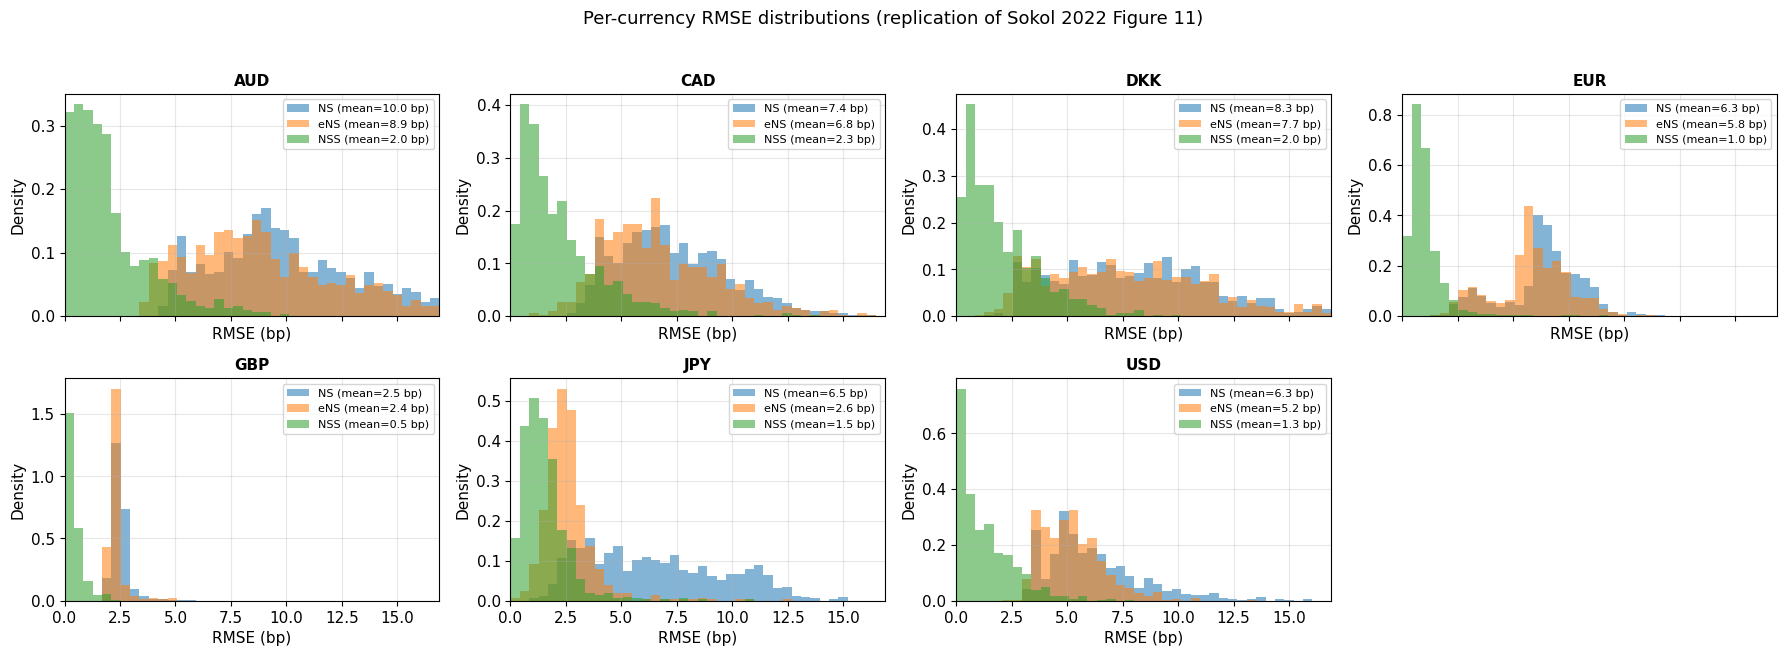

In [70]:
n_ccy = len(CURRENCIES)
n_cols = 4
n_rows = int(np.ceil(n_ccy / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows),
                         squeeze=False, sharex=True)
axes = axes.flatten()

x_max = np.percentile(
    np.concatenate([fit_results[c]["ns"]["rmse"] for c in CURRENCIES]), 99)

for ax, ccy in zip(axes, CURRENCIES):
    R = fit_results[ccy]
    for model_name, key, color in [
        ("NS",  "ns",  "tab:blue"),
        ("eNS", "ens", "tab:orange"),
        ("NSS", "nss", "tab:green"),
    ]:
        arr = R[key]["rmse"]
        ax.hist(arr, bins=40, alpha=0.55, density=True, range=(0, x_max),
                label=f"{model_name} (mean={arr.mean():.1f} bp)",
                color=color)
    ax.set_title(ccy, fontsize=11, fontweight="bold")
    ax.set_xlabel("RMSE (bp)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(0, x_max)

for ax in axes[n_ccy:]:
    ax.set_visible(False)

fig.suptitle("Per-currency RMSE distributions (replication of Sokol 2022 Figure 11)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02c_rmse_per_ccy.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 — Pooled RMSE distribution (Figures 9–10 of the paper)

Sokol's Figures 9 and 10 pool all currencies and show the distribution of RMSE for each method.
This is the figure that most directly supports the paper's main claim, so we reproduce it carefully.

Here we only have the classical methods — the NS vs VAE vs CVAE comparison comes in nb4.


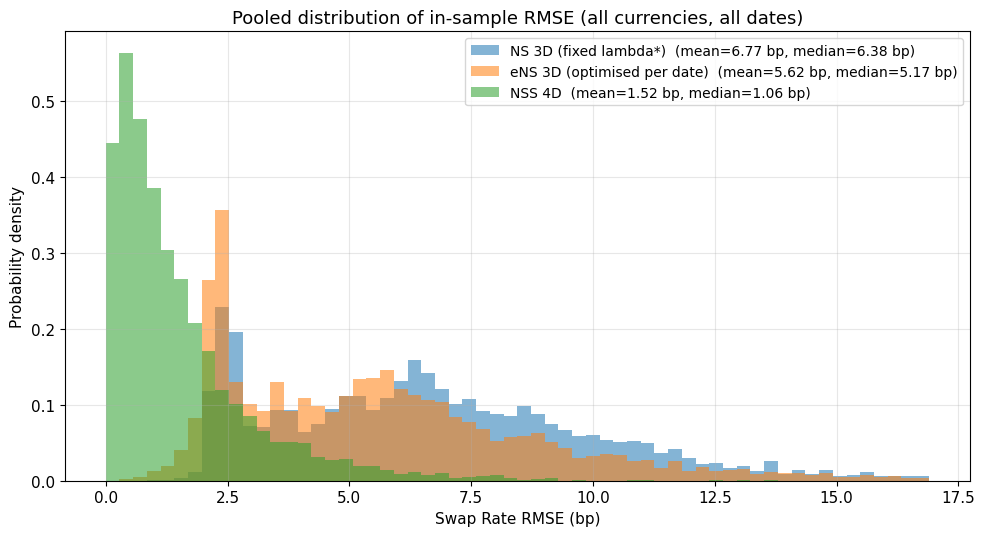

In [71]:
pooled_ns  = np.concatenate([fit_results[c]["ns"]["rmse"]  for c in CURRENCIES])
pooled_ens = np.concatenate([fit_results[c]["ens"]["rmse"] for c in CURRENCIES])
pooled_nss = np.concatenate([fit_results[c]["nss"]["rmse"] for c in CURRENCIES])

fig, ax = plt.subplots(figsize=(10, 5.5))
x_max = np.percentile(pooled_ns, 99)

for arr, name, color in [
    (pooled_ns,  "NS 3D (fixed lambda*)", "tab:blue"),
    (pooled_ens, "eNS 3D (optimised per date)", "tab:orange"),
    (pooled_nss, "NSS 4D", "tab:green"),
]:
    ax.hist(arr, bins=60, density=True, alpha=0.55, range=(0, x_max),
            label=f"{name}  (mean={arr.mean():.2f} bp, "
                  f"median={np.median(arr):.2f} bp)",
            color=color)

ax.set_xlabel("Swap Rate RMSE (bp)")
ax.set_ylabel("Probability density")
ax.set_title("Pooled distribution of in-sample RMSE (all currencies, all dates)",
             fontsize=13)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02d_rmse_pooled.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — NS latent factor time series

The three NS factors $(\beta_1, \beta_2, \beta_3)$ interpreted as level, slope, and curvature.
This panel is exactly the data that Dynamic Nelson-Siegel models consume (Diebold & Li 2006), so
it will be reused in nb7 (P-measure AEMM vs DNS).

### Cross-validation against the nb1 proxies

Notebook 1 computed three **model-free proxies** for level, slope, and curvature:

- `level`     = mean of the 7 swap rates,
- `slope`     = 30Y − 2Y,
- `curvature` = 2·10Y − 2Y − 30Y.

If our NS fit is sensible, the NS factors should be highly correlated with these proxies. We check
this correlation as a sanity test on the whole fitting pipeline.


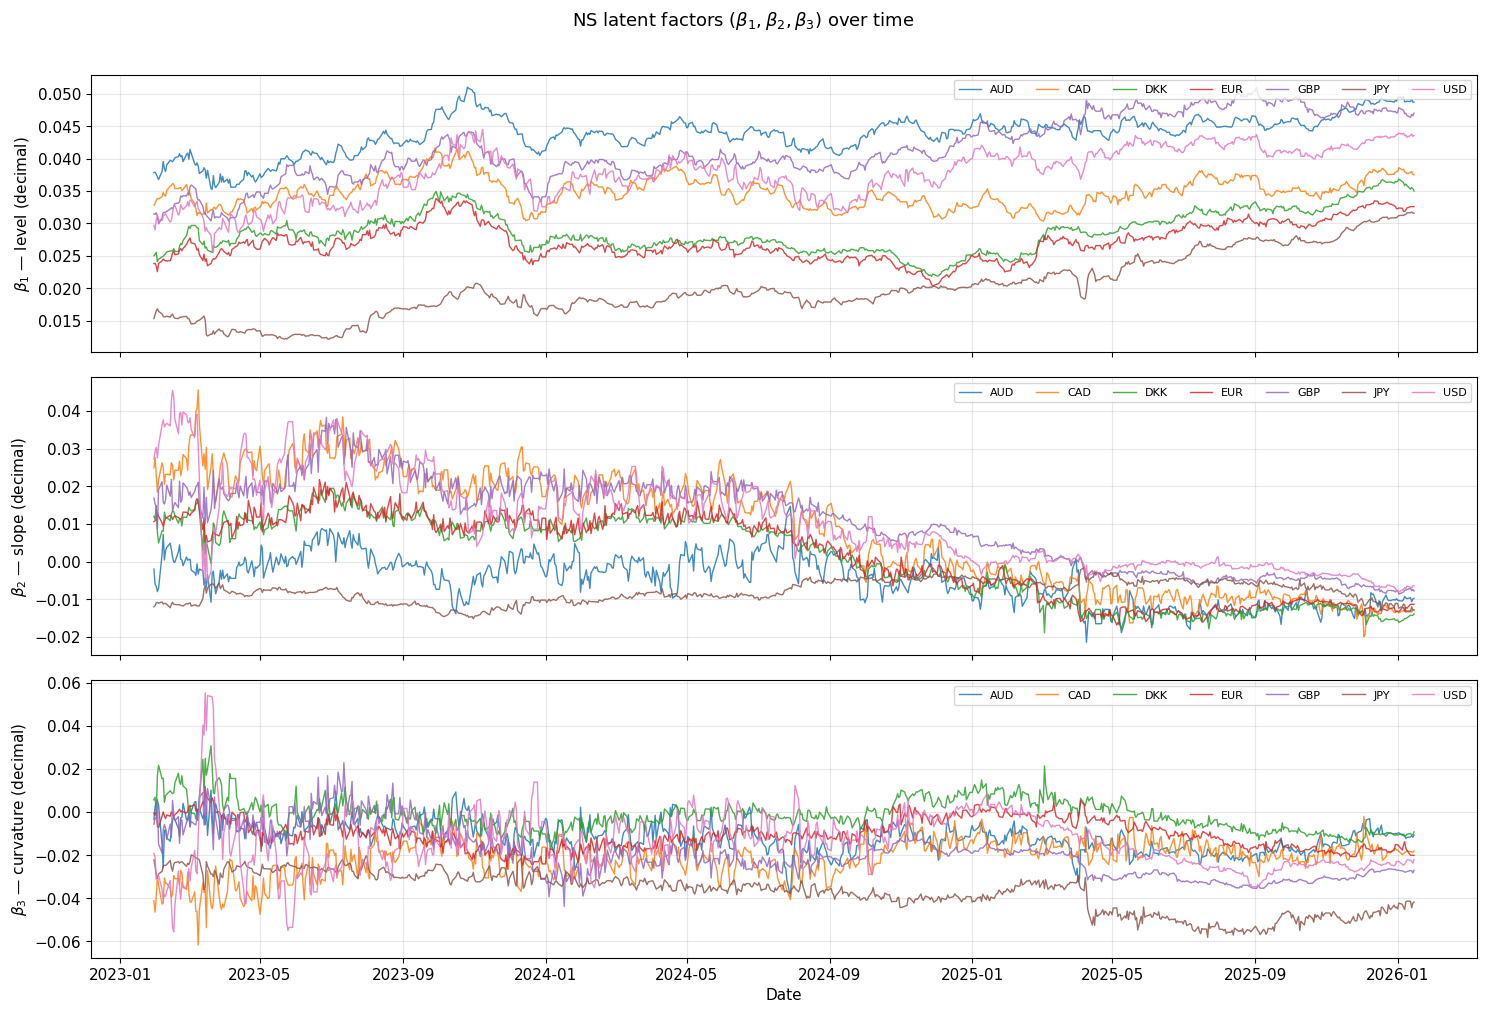

In [72]:
# Build ns_factors[ccy] = DataFrame with columns [beta1, beta2, beta3]
ns_factors = {
    ccy: pd.DataFrame(
        fit_results[ccy]["ns"]["betas"],
        index=fit_results[ccy]["dates"],
        columns=["beta1", "beta2", "beta3"],
    )
    for ccy in CURRENCIES
}

# Time series plot
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
factor_labels = [
    r"$\beta_1$ — level (decimal)",
    r"$\beta_2$ — slope (decimal)",
    r"$\beta_3$ — curvature (decimal)",
]

for k, (ax, label) in enumerate(zip(axes, factor_labels)):
    for ccy in CURRENCIES:
        ax.plot(ns_factors[ccy].index, ns_factors[ccy].iloc[:, k],
                label=ccy, linewidth=1.0, alpha=0.85)
    ax.set_ylabel(label)
    ax.legend(loc="upper right", ncol=len(CURRENCIES), fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle(r"NS latent factors $(\beta_1, \beta_2, \beta_3)$ over time",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02e_ns_factors_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

In [73]:
# Correlation check: NS factors vs model-free proxies
print("Correlation of NS factors with model-free proxies (per currency):")
print("(expected: beta1~level positive, beta2~slope negative, beta3~curvature loose)")
print()
print(f"{'ccy':<5} {'corr(b1,level)':>15} {'corr(b2,slope)':>16} {'corr(b3,curv)':>15}")
print("-" * 55)
for ccy in CURRENCIES:
    df = swap_aligned[ccy]
    betas = ns_factors[ccy]

    level_proxy     = df.mean(axis=1)
    slope_proxy     = df[30] - df[2]
    curvature_proxy = 2 * df[10] - df[2] - df[30]

    c1 = betas["beta1"].corr(level_proxy)
    c2 = betas["beta2"].corr(slope_proxy)
    c3 = betas["beta3"].corr(curvature_proxy)
    print(f"{ccy:<5} {c1:>15.3f} {c2:>16.3f} {c3:>15.3f}")

Correlation of NS factors with model-free proxies (per currency):
(expected: beta1~level positive, beta2~slope negative, beta3~curvature loose)

ccy    corr(b1,level)   corr(b2,slope)   corr(b3,curv)
-------------------------------------------------------
AUD             0.662           -0.924           0.361
CAD             0.583           -0.983           0.650
DKK             0.402           -0.970           0.106
EUR             0.406           -0.970           0.312
GBP             0.256           -0.980          -0.550
JPY             0.986           -0.092           0.923
USD             0.420           -0.942           0.368


### Interpretation of the correlation table

The **slope** correlation (NS $\beta_2$ vs 30Y−2Y) is between $-0.92$ and $-0.98$ for all
currencies **except JPY** where it collapses to $\sim -0.09$. This is not a bug: over our
three-year window, JPY spent most of its time in an upward-sloping regime with the slope barely
changing, while $\beta_1$ was absorbing almost all of the level variation (hence its $0.99$
correlation with the mean rate). The roles of level and slope blur when one of them is nearly
constant.

For the other currencies, the **level** correlation is weaker than one might expect (0.25–0.66)
because $\beta_1$ is the *asymptotic long rate* while the proxy is the *average over 7 tenors*;
the two coincide only in the limit of a flat curve. The sign and magnitude are still what the NS
model predicts.

The **curvature** correlation is the least reliable one because the NS curvature basis is a
smooth peaked function, while the butterfly proxy $2\cdot 10Y - 2Y - 30Y$ is a crude linear
combination. They should share a general trend but not match pointwise. GBP even gets a negative
correlation — expected when the curve's hump moves outside the maturity range covered by the proxy.

**Bottom line**: the NS factors are consistent with their standard economic interpretation on 6 of
the 7 currencies, with JPY being an explained outlier. The fitting pipeline is sound.


## 10 — Example fits: best, median, and worst dates per currency

Three rows per currency:

- **Best**   — the date where NS fits best (smallest RMSE),
- **Median** — a typical day,
- **Worst**  — the date where NS fails the most.

On each panel we overlay the market rates (dots) with NS, eNS, and NSS reconstructions. This
figure is invaluable to understand *why* NS fails on some dates — typically when the curve has
a pronounced hump that a 3-factor model cannot capture.


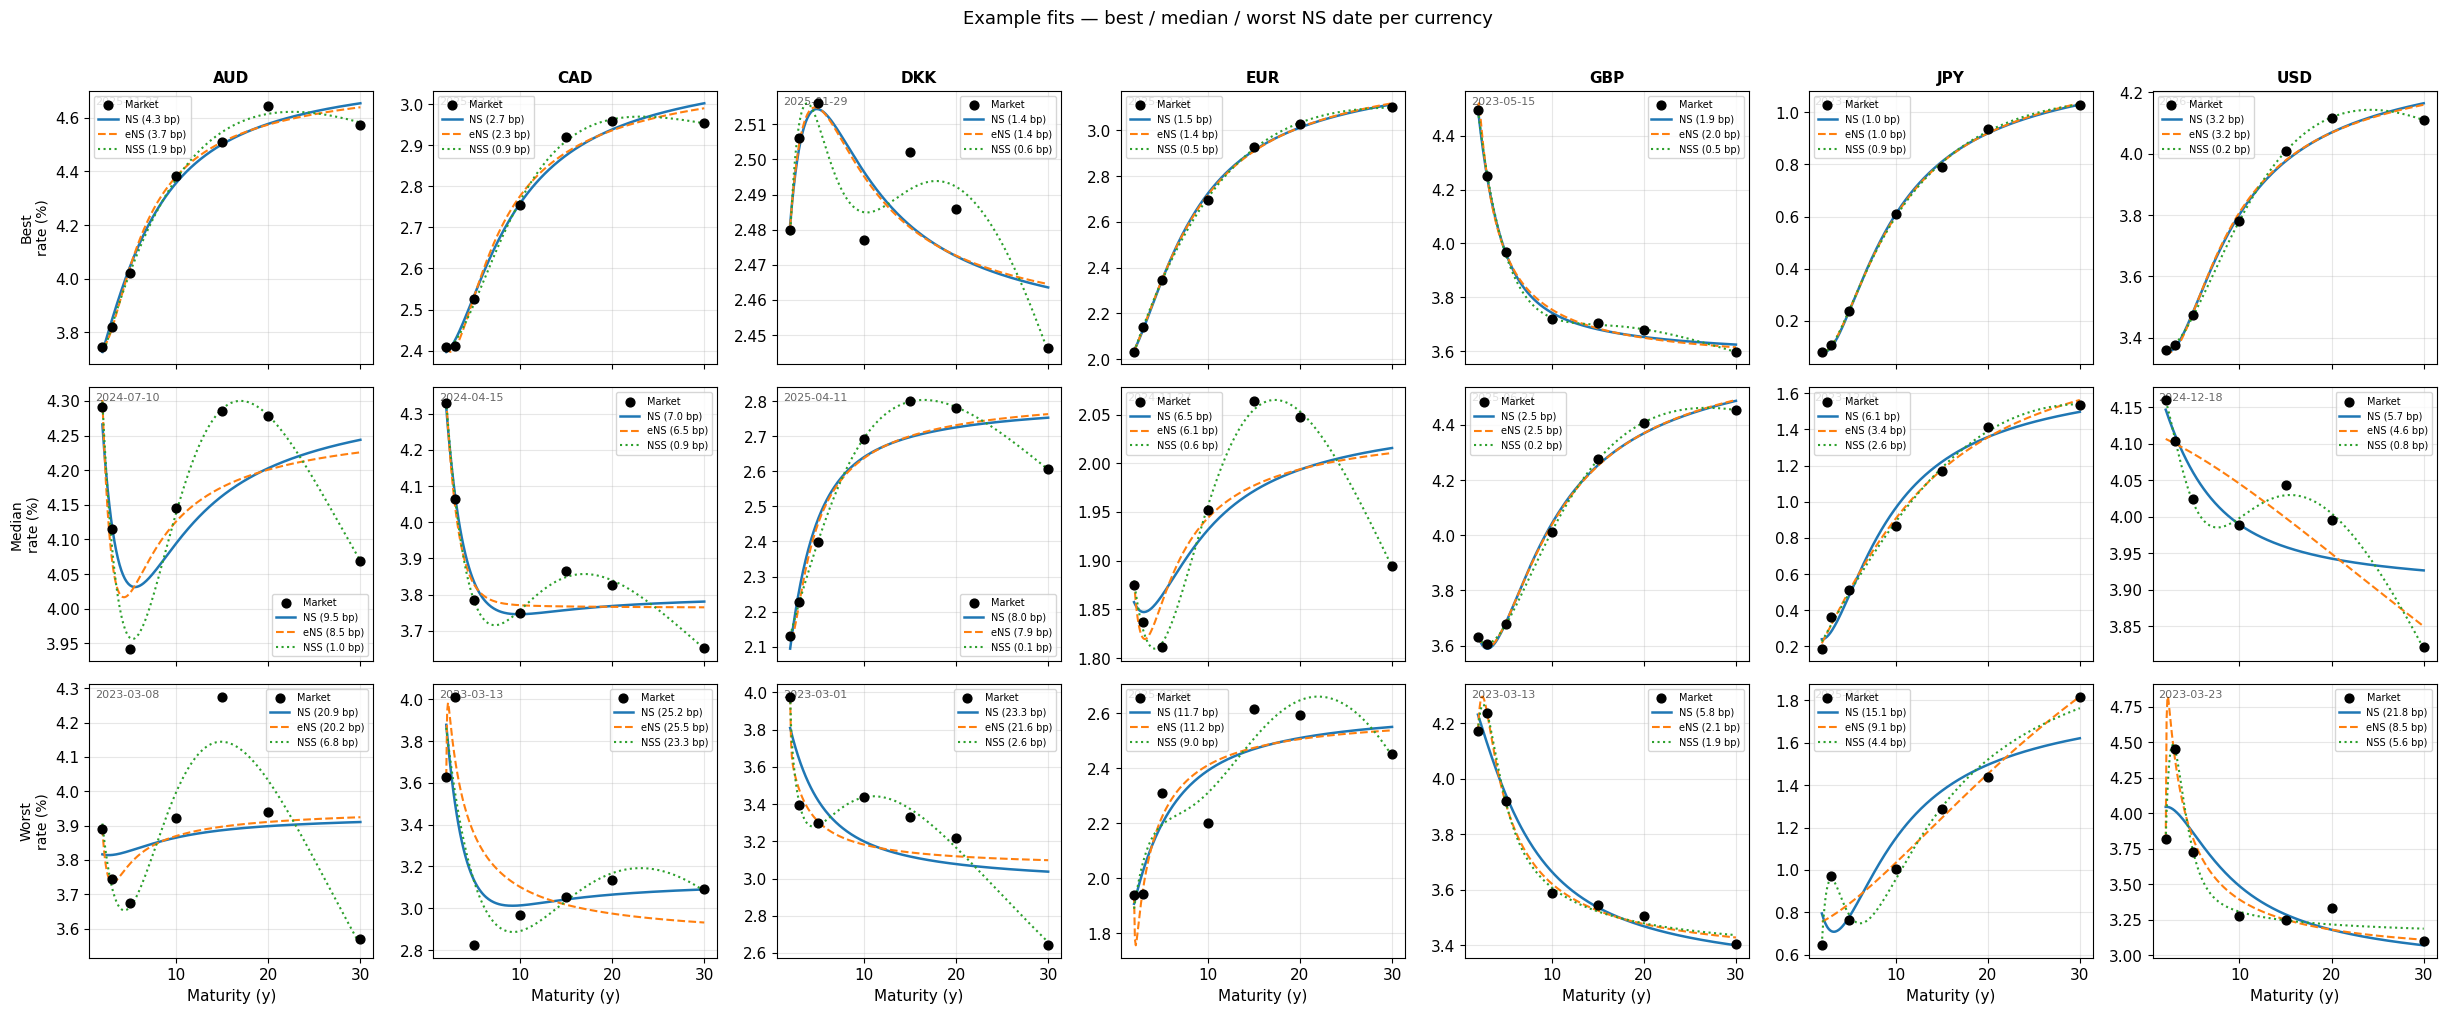

In [74]:
tau_fine = np.linspace(TENORS.min(), TENORS.max(), 300)

fig, axes = plt.subplots(3, n_ccy, figsize=(3.5 * n_ccy, 10), squeeze=False, sharex=True)
row_titles = ["Best", "Median", "Worst"]

for j, ccy in enumerate(CURRENCIES):
    R = fit_results[ccy]
    rmses = R["ns"]["rmse"]
    order = np.argsort(rmses)
    idx_best   = int(order[0])
    idx_median = int(order[len(order) // 2])
    idx_worst  = int(order[-1])

    for row, idx in enumerate([idx_best, idx_median, idx_worst]):
        ax = axes[row, j]
        rates = R["rates"][idx]
        date  = R["dates"][idx]

        # Reconstruct each model on a fine maturity grid for nice curves.
        ns_curve  = ns_basis(tau_fine, LAM_STAR) @ R["ns"]["betas"][idx]
        ens_curve = ns_basis(tau_fine, R["ens"]["lam"][idx]) @ R["ens"]["betas"][idx]
        nss_curve = nss_basis(tau_fine, R["nss"]["lam1"][idx], R["nss"]["lam2"][idx]) @ R["nss"]["betas"][idx]

        ax.scatter(TENORS, 100 * rates, color="black", s=40, zorder=5, label="Market")
        ax.plot(tau_fine, 100 * ns_curve,  color="tab:blue",   linewidth=1.8,
                label=f"NS ({R['ns']['rmse'][idx]:.1f} bp)")
        ax.plot(tau_fine, 100 * ens_curve, color="tab:orange", linewidth=1.5, linestyle="--",
                label=f"eNS ({R['ens']['rmse'][idx]:.1f} bp)")
        ax.plot(tau_fine, 100 * nss_curve, color="tab:green",  linewidth=1.5, linestyle=":",
                label=f"NSS ({R['nss']['rmse'][idx]:.1f} bp)")

        if row == 0:
            ax.set_title(f"{ccy}", fontsize=11, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{row_titles[row]}\nrate (%)", fontsize=10)
        if row == 2:
            ax.set_xlabel("Maturity (y)")

        ax.legend(fontsize=7, loc="best")
        # Annotate the date discreetly
        ax.text(0.02, 0.98, str(date.date()),
                transform=ax.transAxes, fontsize=8, va="top", alpha=0.6)

fig.suptitle("Example fits — best / median / worst NS date per currency",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02f_example_fits.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 — Per-tenor residuals heatmap

Where, along the maturity axis, does NS fail? We compute the **mean absolute residual** per
`(currency, tenor)` and display it as a heatmap. If NS is systematically missing, say, the 15Y
point, that shows up as a bright cell.


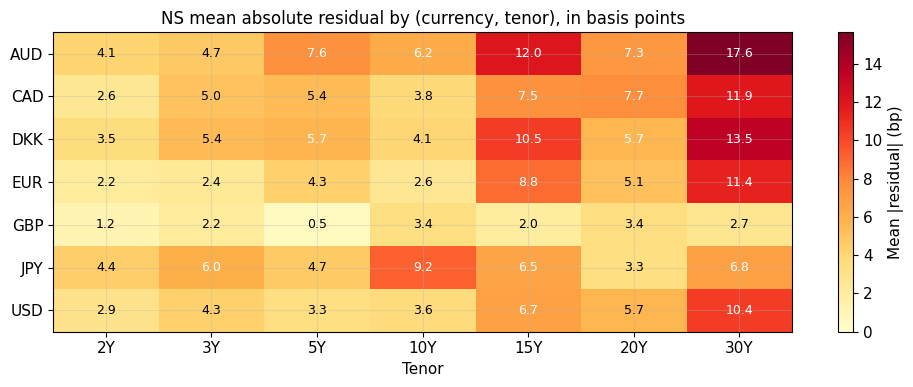

In [75]:
resid_matrix = np.zeros((len(CURRENCIES), len(TENORS)))
for i, ccy in enumerate(CURRENCIES):
    res = fit_results[ccy]["ns"]["residuals"]
    resid_matrix[i] = np.mean(np.abs(res), axis=0) * BP_PER_UNIT

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(resid_matrix, aspect="auto", cmap="YlOrRd",
               vmin=0, vmax=np.percentile(resid_matrix, 99))
ax.set_xticks(range(len(TENORS)))
ax.set_xticklabels([f"{int(t)}Y" for t in TENORS])
ax.set_yticks(range(len(CURRENCIES)))
ax.set_yticklabels(CURRENCIES)
ax.set_xlabel("Tenor")
ax.set_title("NS mean absolute residual by (currency, tenor), in basis points",
             fontsize=12)

# Annotate each cell with its numeric value.
for i in range(len(CURRENCIES)):
    for j in range(len(TENORS)):
        ax.text(j, i, f"{resid_matrix[i, j]:.1f}",
                ha="center", va="center", fontsize=9,
                color="white" if resid_matrix[i, j] > np.percentile(resid_matrix, 60)
                      else "black")

plt.colorbar(im, ax=ax, label="Mean |residual| (bp)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02g_residuals_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**What this tells us.** NS errors are not uniform across maturities. You will typically see
larger residuals at the long end (20Y, 30Y) and at 15Y — these are the points where a 3-factor
parametric form struggles to bend enough. This structural failure of NS is exactly the weakness
the VAE is supposed to fix in nb3: the VAE has the freedom to learn a non-parametric decoder that
can handle whatever shapes appear in the historical data.


## 12 — Save results to pickle

The output pickle is designed for three downstream notebooks:

- **nb3 (VAE training)** — doesn't read this pickle directly; no dependency.
- **nb4 (comparison)**  — reads per-date RMSE as `DataFrames` indexed by date, for Wilcoxon tests.
- **nb7 (P-measure AEMM vs DNS)** — reads the NS factor time series `(beta_1, beta_2, beta_3)`.


In [77]:
# Per-model per-currency RMSE DataFrames (indexed by date).
rmse_ns_df  = pd.DataFrame({c: fit_results[c]["ns"]["rmse"]  for c in CURRENCIES},
                           index=swap_aligned[CURRENCIES[0]].index)
rmse_ens_df = pd.DataFrame({c: fit_results[c]["ens"]["rmse"] for c in CURRENCIES},
                           index=swap_aligned[CURRENCIES[0]].index)
rmse_nss_df = pd.DataFrame({c: fit_results[c]["nss"]["rmse"] for c in CURRENCIES},
                           index=swap_aligned[CURRENCIES[0]].index)

# eNS lambdas time series
ens_lambda_df = pd.DataFrame(
    {c: fit_results[c]["ens"]["lam"] for c in CURRENCIES},
    index=swap_aligned[CURRENCIES[0]].index,
)

# NSS (lam1, lam2) time series
nss_lam1_df = pd.DataFrame(
    {c: fit_results[c]["nss"]["lam1"] for c in CURRENCIES},
    index=swap_aligned[CURRENCIES[0]].index,
)
nss_lam2_df = pd.DataFrame(
    {c: fit_results[c]["nss"]["lam2"] for c in CURRENCIES},
    index=swap_aligned[CURRENCIES[0]].index,
)

ns_output = {
    # config
    "currencies":       CURRENCIES,
    "target_tenors":    TARGET_TENORS,
    "lambda_star":      LAM_STAR,
    "lambda_grid":      lam_grid,
    "lambda_cv_curve":  mean_rmse_per_lam,
    "bp_per_unit":      BP_PER_UNIT,
    "excluded":         sorted(EXCLUDE_CURRENCIES),

    # fitted quantities
    "ns_factors":       ns_factors,           # dict[ccy -> DataFrame(date, [beta1,beta2,beta3])]
    "rmse_ns_df":       rmse_ns_df,
    "rmse_ens_df":      rmse_ens_df,
    "rmse_nss_df":      rmse_nss_df,
    "ens_lambda_df":    ens_lambda_df,
    "nss_lam1_df":      nss_lam1_df,
    "nss_lam2_df":      nss_lam2_df,

    # full per-date structures (heavy but useful for deep dive in nb4)
    "fit_results":      fit_results,
}

with open("results/ns_results.pkl", "wb") as f:
    pickle.dump(ns_output, f)

print("Saved ns_results.pkl")
print(f"  lambda* = {LAM_STAR:.4f}")
print(f"  currencies = {CURRENCIES}")
print(f"  rmse_ns_df shape = {rmse_ns_df.shape}")

Saved ns_results.pkl
  lambda* = 0.5000
  currencies = ['AUD', 'CAD', 'DKK', 'EUR', 'GBP', 'JPY', 'USD']
  rmse_ns_df shape = (774, 7)
